State label column: name


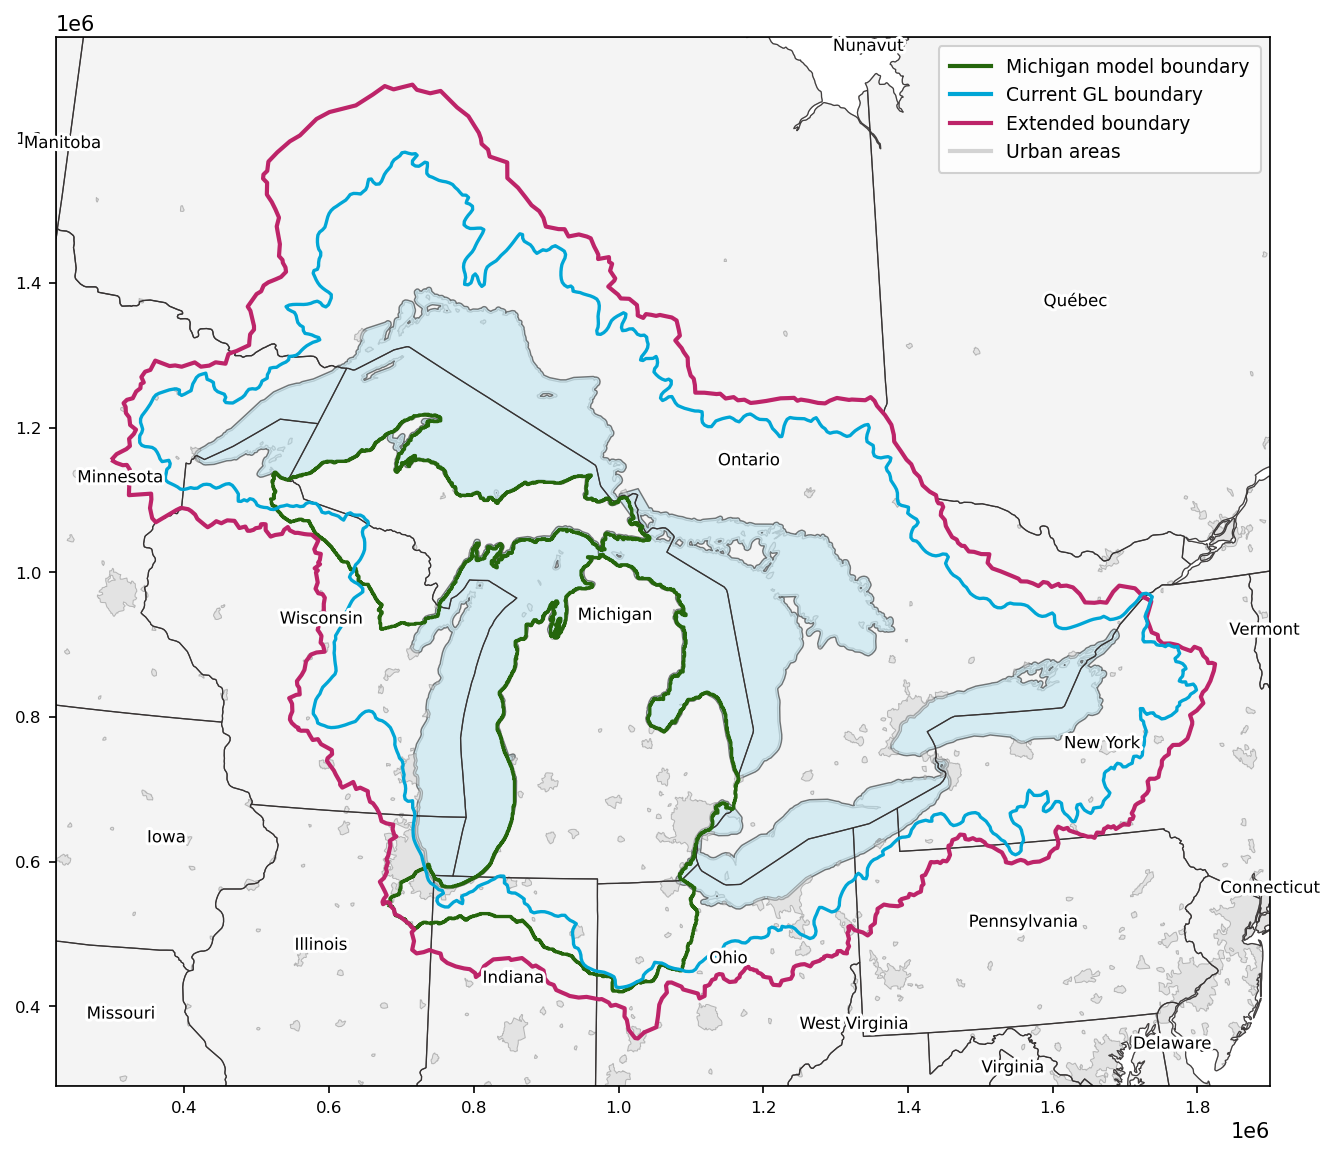

Saved: D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\StudydomainGL.jpeg


In [1]:
# ===== Boundaries + STATES (with names) — EPSG:3174, extent padded from extended_bdry =====
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from shapely.geometry import box
import geopandas as gpd

TARGET_CRS = "EPSG:3174"   # Michigan Oblique Mercator (meters)

# -------------------------
# Helpers
# -------------------------
def ensure_and_to_crs(gdf: gpd.GeoDataFrame, to_crs: str, assume_epsg4326_if_none=True, name="layer"):
    if gdf is None:
        return gpd.GeoDataFrame(geometry=[], crs=to_crs)
    if len(gdf) == 0:
        if gdf.crs is None:
            gdf = gdf.set_crs(to_crs)
        else:
            gdf = gdf.to_crs(to_crs)
        return gdf
    if gdf.crs is None:
        if assume_epsg4326_if_none:
            gdf = gdf.set_crs("EPSG:4326")
        else:
            raise ValueError(f"{name} has no CRS. Set its CRS before reprojecting.")
    return gdf.to_crs(to_crs)

def dissolve_one(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)
    return gdf.dissolve().reset_index(drop=True)

def pad_bounds(bounds, pad_frac=0.05):
    minx, miny, maxx, maxy = bounds
    dx = (maxx - minx) * pad_frac
    dy = (maxy - miny) * pad_frac
    return (minx - dx, miny - dy, maxx + dx, maxy + dy)

def choose_label_col(gdf, candidates):
    for c in candidates:
        if c in gdf.columns:
            return c
    # fallback: first non-geometry column
    for c in gdf.columns:
        if c != "geometry":
            return c
    return None

def label_polys(ax, gdf, label_col, fontsize=8, min_sep_m=140_000, zorder=20):
    """
    Label polygons using representative_point(), skipping labels that are too close.
    min_sep_m is in meters (EPSG:3174).
    """
    if gdf is None or len(gdf) == 0 or label_col is None or label_col not in gdf.columns:
        return

    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    if len(gdf) == 0:
        return

    gdf["rp"] = gdf.geometry.representative_point()

    placed = []
    for _, row in gdf.iterrows():
        x, y = row["rp"].x, row["rp"].y
        txt = str(row[label_col])

        if placed:
            dx = np.array([x - px for px, py in placed])
            dy = np.array([y - py for px, py in placed])
            if np.min(np.hypot(dx, dy)) < min_sep_m:
                continue

        ax.text(
            x, y, txt,
            fontsize=fontsize, ha="center", va="center", color="black",
            zorder=zorder,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )
        placed.append((x, y))

# -------------------------
# Read layers
# -------------------------
michigan      = gpd.read_file(r"S:\Projects\Active\Michigan_Model\Model_Boundary\Model_Grid_Surface_Active_Boundary.shp")
extended_bdry = gpd.read_file(r"D:\Users\abolmaal\modelling\Modflow\Prep\GreatLakes\model_Layers\Ibound\extended_Bdry_final_GLB_Albers_exported.shp")
sigler_bdry   = gpd.read_file(r"S:\Users\Samin\Data\Derived\Sigler_IBound\huc2Poly.shp")

countries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_0_countries_lakes.shp"
)
Great_Lakes = gpd.read_file(r"D:\Users\abolmaal\data\MI_Model\Natural_Earth_Great_Lakes_Buffer_Edit.shp")
State_Boundaries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_1_states_provinces.shp"
)
urban_areas = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_urban_areas.shp"
)
# -------------------------
# Reproject to EPSG:3174
# -------------------------
countries        = ensure_and_to_crs(countries,        TARGET_CRS, assume_epsg4326_if_none=True,  name="countries")
Great_Lakes      = ensure_and_to_crs(Great_Lakes,      TARGET_CRS, assume_epsg4326_if_none=True,  name="Great_Lakes")
michigan         = ensure_and_to_crs(michigan,         TARGET_CRS, assume_epsg4326_if_none=False, name="michigan")
extended_bdry    = ensure_and_to_crs(extended_bdry,    TARGET_CRS, assume_epsg4326_if_none=False, name="extended_bdry")
sigler_bdry      = ensure_and_to_crs(sigler_bdry,      TARGET_CRS, assume_epsg4326_if_none=False, name="sigler_bdry")
State_Boundaries = ensure_and_to_crs(State_Boundaries, TARGET_CRS, assume_epsg4326_if_none=True,  name="State_Boundaries")
urban_areas      = ensure_and_to_crs(urban_areas,      TARGET_CRS, assume_epsg4326_if_none=True,  name="urban_areas")
# Dissolve (clean single outlines)
mi_one  = dissolve_one(michigan)
ext_one = dissolve_one(extended_bdry)
sig_one = dissolve_one(sigler_bdry)

# -------------------------
# Extent: padded from extended_bdry
# -------------------------
x0, y0, x1, y1 = pad_bounds(ext_one.total_bounds, pad_frac=0.05)
roi = box(x0, y0, x1, y1)
roi_gdf = gpd.GeoDataFrame(geometry=[roi], crs=TARGET_CRS)

# Clip layers to ROI
countries_roi = gpd.clip(countries, roi_gdf)
states_roi    = gpd.clip(State_Boundaries, roi_gdf)
urban_areas_roi = gpd.clip(urban_areas, roi_gdf)

# Choose state label column (Natural Earth usually has: name, name_en, postal)
STATE_LABEL_COL = choose_label_col(states_roi, ["name", "name_en", "postal", "abbr", "abbrev", "iso_3166_2", "NAME"])
print("State label column:", STATE_LABEL_COL)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(9, 9), dpi=150)
ax.set_facecolor("white")

# Basemap
countries_roi.plot(ax=ax, facecolor="#f2f2f2d5", edgecolor="#bdbdbd", linewidth=0.6, zorder=0)
Great_Lakes.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.5, linewidth=0.7, zorder=1)
urban_areas_roi.plot(ax=ax, facecolor="lightgray", edgecolor="gray", alpha=0.5, linewidth=0.5, zorder=1)

# States (boundaries)
states_roi.boundary.plot(ax=ax, color="#353131", linewidth=0.6, alpha=0.9, zorder=2)

# States (names)
label_polys(ax, states_roi, label_col=STATE_LABEL_COL, fontsize=8, min_sep_m=160_000, zorder=10)

# Your boundaries (different colors)
mi_color  = "#25660C"
ext_color = "#BD2469"
sig_color = "#00A6D6"

mi_one.boundary.plot(ax=ax, color=mi_color,  linewidth=1.6, zorder=5)
ext_one.boundary.plot(ax=ax, color=ext_color, linewidth=2.0, zorder=6)
sig_one.boundary.plot(ax=ax, color=sig_color, linewidth=1.6, zorder=6)

# Extent + cosmetics
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(labelsize=8)
ax.set_aspect("equal")

# Legend
legend_elements = [
    Line2D([0], [0], color=mi_color,   lw=2.0, label="Michigan model boundary"),
    Line2D([0], [0], color=sig_color,  lw=2.0, label="Current GL boundary"),
    Line2D([0], [0], color=ext_color,  lw=2.0, label="Extended boundary"),
    Line2D([0], [0], color="lightgray", lw=2.0, label="Urban areas"),
    #Line2D([0], [0], color="#353131",  lw=1.5, label="State boundaries"),
]
ax.legend(
    handles=legend_elements, loc="upper right",
    frameon=True, framealpha=0.9, facecolor="white", edgecolor="#cccccc",
    fontsize=9, handlelength=2.2, borderpad=0.6
)

out_png = r"D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\StudydomainGL.jpeg"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved: {out_png}")

# Debug if needed:
# print("States columns:", list(states_roi.columns))


State label column: name


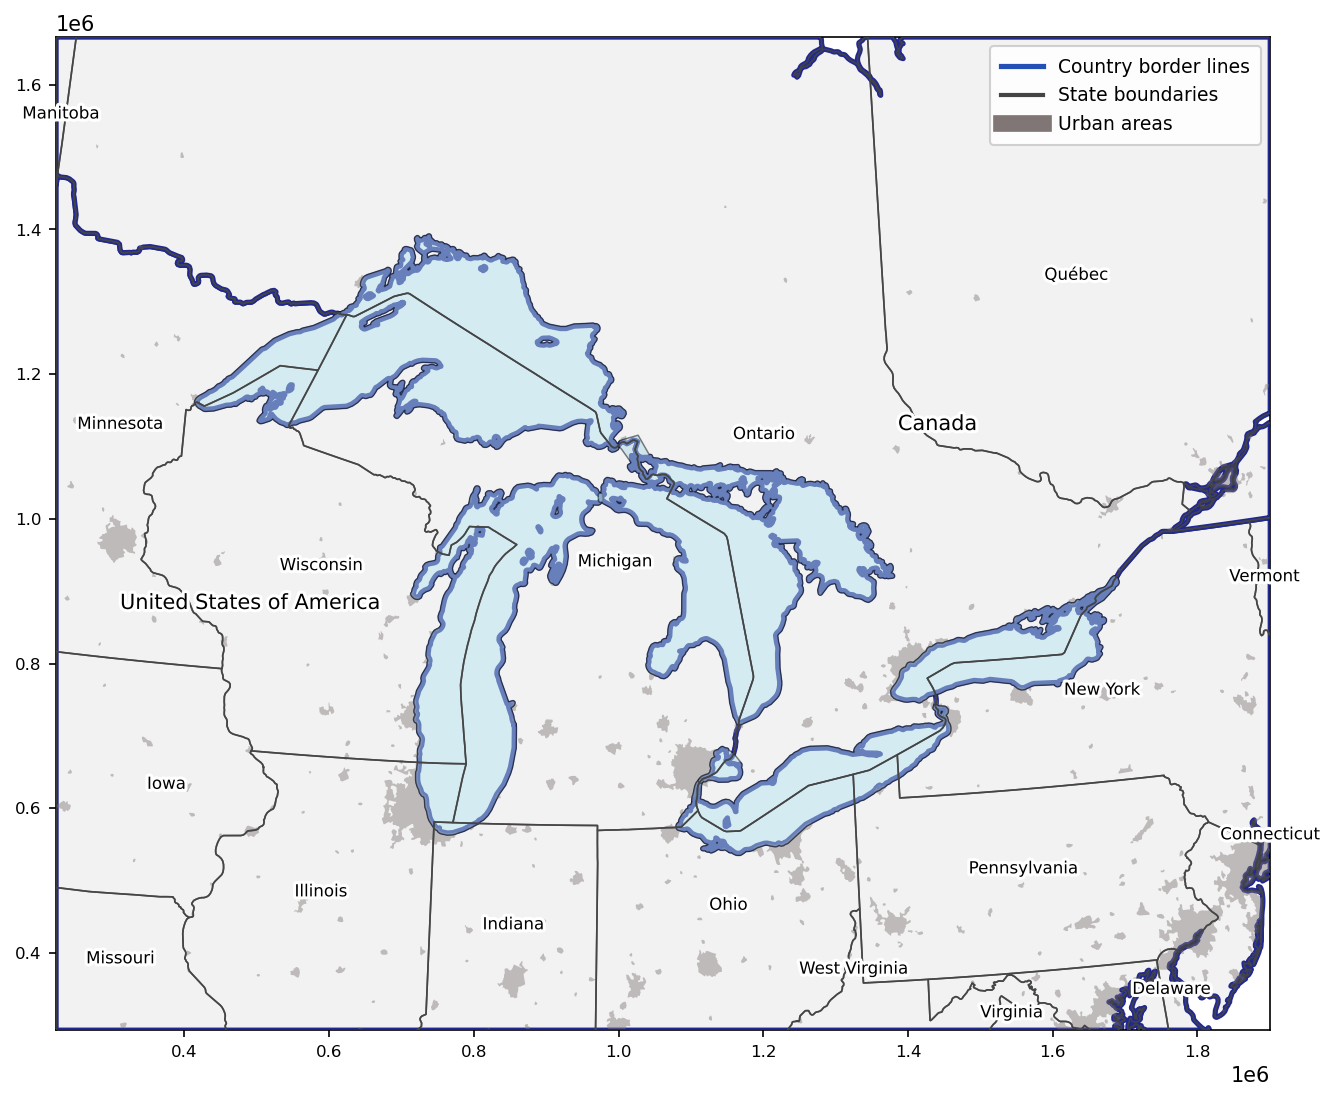

Saved: D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\GreatLakesBasin_withBordersUrban_States.jpeg


In [14]:
# ===== Boundaries ONLY — EPSG:3174, different colors, extent padded from extended_bdry
# + Natural Earth: countries background, border lines, urban areas, Great Lakes
# + ADD: State boundaries + state name labels
# + label selected countries =====

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from shapely.geometry import box
import geopandas as gpd

TARGET_CRS = "EPSG:3174"   # Michigan Oblique Mercator (meters)

# -------------------------
# Helpers
# -------------------------
def ensure_and_to_crs(gdf: gpd.GeoDataFrame, to_crs: str, assume_epsg4326_if_none=True, name="layer"):
    if gdf is None:
        return gpd.GeoDataFrame(geometry=[], crs=to_crs)
    if len(gdf) == 0:
        if gdf.crs is None:
            gdf = gdf.set_crs(to_crs)
        else:
            gdf = gdf.to_crs(to_crs)
        return gdf
    if gdf.crs is None:
        if assume_epsg4326_if_none:
            gdf = gdf.set_crs("EPSG:4326")
        else:
            raise ValueError(f"{name} has no CRS. Set its CRS before reprojecting.")
    return gdf.to_crs(to_crs)

def dissolve_one(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)
    return gdf.dissolve().reset_index(drop=True)

def pad_bounds(bounds, pad_frac=0.05):
    minx, miny, maxx, maxy = bounds
    dx = (maxx - minx) * pad_frac
    dy = (maxy - miny) * pad_frac
    return (minx - dx, miny - dy, maxx + dx, maxy + dy)

def label_polys(ax, gdf, label_col, fontsize=9, min_sep_m=120_000, zorder=20):
    """
    Generic polygon labeler using representative_point(), skipping labels too close.
    min_sep_m is in map units (meters in EPSG:3174).
    """
    if gdf is None or len(gdf) == 0:
        return
    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    if len(gdf) == 0:
        return

    gdf["rp"] = gdf.geometry.representative_point()

    placed = []
    for _, row in gdf.iterrows():
        x, y = row["rp"].x, row["rp"].y
        txt = str(row[label_col])

        if placed:
            dx = np.array([x - px for px, py in placed])
            dy = np.array([y - py for px, py in placed])
            if np.min(np.hypot(dx, dy)) < min_sep_m:
                continue

        ax.text(
            x, y, txt,
            fontsize=fontsize, ha="center", va="center", color="black",
            zorder=zorder,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )
        placed.append((x, y))

# -------------------------
# Read layers
# -------------------------
michigan      = gpd.read_file(r"S:\Data\GIS_Data\Derived\MI_Model\Michigan_UP_LP_Border.shp")
extended_bdry = gpd.read_file(r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp")
sigler_bdry   = gpd.read_file(r"S:\Users\Samin\Data\Derived\Sigler_IBound\huc2Poly.shp")

countries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_0_countries_lakes.shp"
)
border_lines = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_0_boundary_lines_land.shp"
)
urban_areas = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_urban_areas.shp"
)
Great_Lakes = gpd.read_file(r"D:\Users\abolmaal\data\MI_Model\Natural_Earth_Great_Lakes_Buffer_Edit.shp")

# --- ADD YOUR STATE LAYER PATH HERE ---
State_Boundaries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_1_states_provinces.shp"
    # ^ if you already have another states file, replace this path with yours
)

# -------------------------
# Reproject to EPSG:3174
# -------------------------
countries        = ensure_and_to_crs(countries,        TARGET_CRS, assume_epsg4326_if_none=True,  name="countries")
border_lines     = ensure_and_to_crs(border_lines,     TARGET_CRS, assume_epsg4326_if_none=True,  name="border_lines")
urban_areas      = ensure_and_to_crs(urban_areas,      TARGET_CRS, assume_epsg4326_if_none=True,  name="urban_areas")
Great_Lakes      = ensure_and_to_crs(Great_Lakes,      TARGET_CRS, assume_epsg4326_if_none=True,  name="Great_Lakes")

michigan         = ensure_and_to_crs(michigan,         TARGET_CRS, assume_epsg4326_if_none=False, name="michigan")
extended_bdry    = ensure_and_to_crs(extended_bdry,    TARGET_CRS, assume_epsg4326_if_none=False, name="extended_bdry")
sigler_bdry      = ensure_and_to_crs(sigler_bdry,      TARGET_CRS, assume_epsg4326_if_none=False, name="sigler_bdry")

# YOUR REQUESTED LINE (kept exactly)
State_Boundaries = ensure_and_to_crs(State_Boundaries, TARGET_CRS, assume_epsg4326_if_none=True,  name="State_Boundaries")

# Dissolve (clean single outlines)
mi_one  = dissolve_one(michigan)
ext_one = dissolve_one(extended_bdry)
sig_one = dissolve_one(sigler_bdry)

# -------------------------
# Extent: padded from extended_bdry
# -------------------------
x0, y0, x1, y1 = pad_bounds(ext_one.total_bounds, pad_frac=0.05)
roi = box(x0, y0, x1, y1)
roi_gdf = gpd.GeoDataFrame(geometry=[roi], crs=TARGET_CRS)

# Clip background layers to ROI (faster/cleaner)
countries_roi     = gpd.clip(countries, roi_gdf)
border_lines_roi  = gpd.clip(border_lines, roi_gdf)
urban_areas_roi   = gpd.clip(urban_areas, roi_gdf)
states_roi        = gpd.clip(State_Boundaries, roi_gdf)

# -------------------------
# Choose state name field automatically (no guessing needed)
# -------------------------
# Common Natural Earth fields: name, name_en, postal, abbrev, iso_3166_2, etc.
possible_state_cols = ["name", "name_en", "postal", "abbr", "abbrev", "iso_3166_2", "gn_name", "NAME", "STATE_NAME"]
state_label_col = next((c for c in possible_state_cols if c in states_roi.columns), None)
if state_label_col is None:
    # fallback to first non-geometry object column
    non_geom = [c for c in states_roi.columns if c != "geometry"]
    state_label_col = non_geom[0] if non_geom else None
print("State label column:", state_label_col)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(9, 9), dpi=150)
ax.set_facecolor("white")

# Countries (very light fill)
countries_roi.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#212891", linewidth=2.5, zorder=0)

# Urban areas (gray overlay)
urban_areas_roi.plot(ax=ax, facecolor="#807676", edgecolor="none", alpha=0.45, zorder=1)

# Country border lines
border_lines_roi.plot(ax=ax, color="#3c5796", linewidth=0.6, alpha=0.9, zorder=2)

# Great Lakes (light blue)
Great_Lakes.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.5, linewidth=0.7, zorder=3)

# --- States: boundary + labels ---
states_roi.boundary.plot(ax=ax, facecolor="none", edgecolor="#444444", linewidth=0.8, alpha=0.9, zorder=4)

if state_label_col is not None and state_label_col in states_roi.columns:
    # If too cluttered, increase min_sep_m or reduce fontsize
    label_polys(ax, states_roi, label_col=state_label_col, fontsize=8, min_sep_m=140_000, zorder=21)

# --- Your boundaries (uncomment if you want them on the map) ---
mi_color  = "black"
ext_color = "#7A1FA2"   # purple
sig_color = "#00A6D6"   # cyan/blue

# mi_one.boundary.plot(ax=ax, color=mi_color,   linewidth=1.2, zorder=10)
# ext_one.boundary.plot(ax=ax, color=ext_color, linewidth=1.6, zorder=11)
# sig_one.boundary.plot(ax=ax, color=sig_color, linewidth=1.3, zorder=11)

# -------------------------
# Country labels (edit list as you want)
# -------------------------
LABEL_COL = "ADMIN"
WANTED_COUNTRIES = [
    "United States of America",
    "Canada",
    # add more if they fall inside your ROI
]
countries_lbl = countries_roi[countries_roi[LABEL_COL].isin(WANTED_COUNTRIES)].copy()
label_polys(ax, countries_lbl, label_col=LABEL_COL, fontsize=10, min_sep_m=220_000, zorder=22)

# Extent + cosmetics
ax.set_xlim(x0, x1)
ax.set_ylim(y0, y1)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(labelsize=8)
ax.set_aspect("equal")

# Legend
legend_elements = [
    Line2D([0], [0], color="#234fb6", lw=2.5, label="Country border lines"),
    Line2D([0], [0], color="#444444", lw=2.0, label="State boundaries"),
    Line2D([0], [0], color="#807676", lw=8,   label="Urban areas"),
    # Line2D([0], [0], color=mi_color,  lw=2.0, label="Michigan boundary"),
    # Line2D([0], [0], color=ext_color, lw=2.0, label="Extended boundary"),
    # Line2D([0], [0], color=sig_color, lw=2.0, label="Sigler boundary"),
]
ax.legend(
    handles=legend_elements, loc="upper right",
    frameon=True, framealpha=0.9, facecolor="white", edgecolor="#cccccc",
    fontsize=9, handlelength=2.2, borderpad=0.6
)

out_png = r"D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\GreatLakesBasin_withBordersUrban_States.jpeg"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved: {out_png}")

# Debug helpers:
# print("States columns:", list(states_roi.columns))
# print(sorted(countries_roi["ADMIN"].unique()))


State label column: name


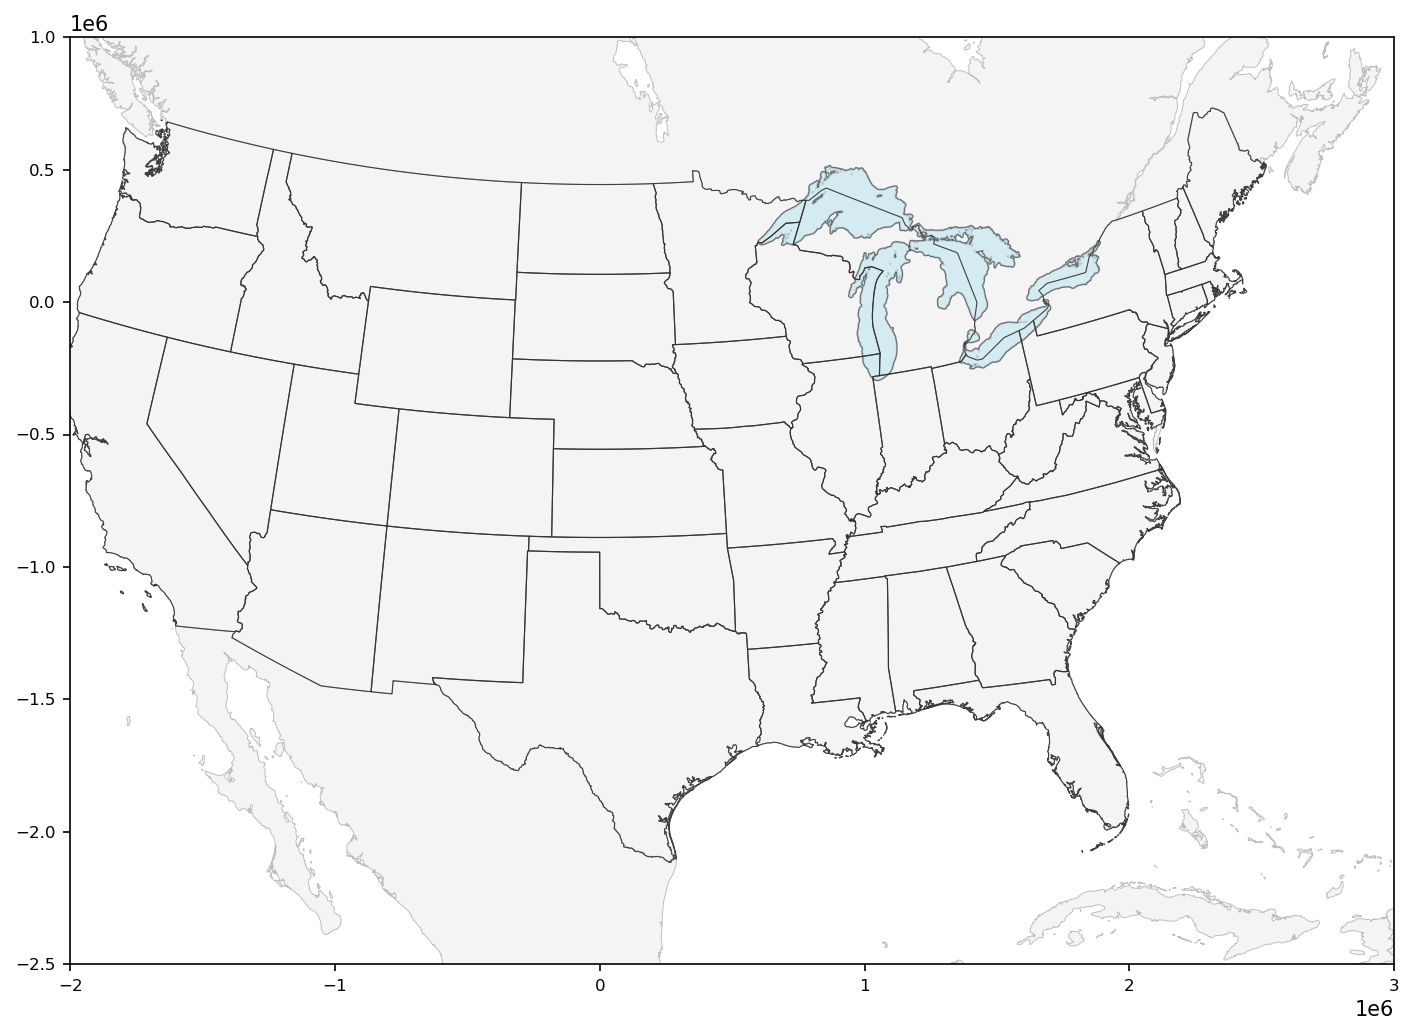

Saved: D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\Greatlake_withUSStates.jpeg


In [23]:
# ===== CONUS ONLY (no Alaska/Hawaii) — states + state names + your model boundaries =====
# Uses EPSG:2163 (good for US-wide maps). Filters Natural Earth states to lower-48.
# Extent is derived from the lower-48 states bounds (padded).

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe
from shapely.geometry import box
import geopandas as gpd

TARGET_CRS = "EPSG:2163"   # US National Atlas Equal Area (meters) — good for CONUS

# -------------------------
# Helpers
# -------------------------
def ensure_and_to_crs(gdf: gpd.GeoDataFrame, to_crs: str, assume_epsg4326_if_none=True, name="layer"):
    if gdf is None:
        return gpd.GeoDataFrame(geometry=[], crs=to_crs)
    if len(gdf) == 0:
        if gdf.crs is None:
            gdf = gdf.set_crs(to_crs)
        else:
            gdf = gdf.to_crs(to_crs)
        return gdf
    if gdf.crs is None:
        if assume_epsg4326_if_none:
            gdf = gdf.set_crs("EPSG:4326")
        else:
            raise ValueError(f"{name} has no CRS. Set its CRS before reprojecting.")
    return gdf.to_crs(to_crs)

def dissolve_one(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    if gdf is None or len(gdf) == 0:
        return gpd.GeoDataFrame(geometry=[], crs=gdf.crs if gdf is not None else None)
    return gdf.dissolve().reset_index(drop=True)

def pad_bounds(bounds, pad_frac=0.03):
    minx, miny, maxx, maxy = bounds
    dx = (maxx - minx) * pad_frac
    dy = (maxy - miny) * pad_frac
    return (minx - dx, miny - dy, maxx + dx, maxy + dy)

def choose_label_col(gdf, candidates):
    for c in candidates:
        if c in gdf.columns:
            return c
    for c in gdf.columns:
        if c != "geometry":
            return c
    return None

def label_polys(ax, gdf, label_col, fontsize=7, min_sep_m=280_000, zorder=20):
    """Label polygons using representative_point(), skipping labels too close (meters in EPSG:2163)."""
    if gdf is None or len(gdf) == 0 or label_col is None or label_col not in gdf.columns:
        return

    gdf = gdf.copy()
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].copy()
    if len(gdf) == 0:
        return

    gdf["rp"] = gdf.geometry.representative_point()

    placed = []
    for _, row in gdf.iterrows():
        x, y = row["rp"].x, row["rp"].y
        txt = str(row[label_col])

        if placed:
            dx = np.array([x - px for px, py in placed])
            dy = np.array([y - py for px, py in placed])
            if np.min(np.hypot(dx, dy)) < min_sep_m:
                continue

        ax.text(
            x, y, txt,
            fontsize=fontsize, ha="center", va="center", color="black",
            zorder=zorder,
            path_effects=[pe.withStroke(linewidth=3, foreground="white")]
        )
        placed.append((x, y))

def filter_us_states_to_conus(states: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Filter Natural Earth admin_1 states/provinces to:
      - United States of America
      - exclude Alaska + Hawaii (and optional territories)
    Tries multiple column options to be robust.
    """
    cols = {c.lower(): c for c in states.columns}

    def has(c): return c in cols
    def col(c): return cols[c]

    s = states.copy()

    # keep only US entries
    if has("admin"):
        s = s[s[col("admin")].astype(str).str.contains("United States", na=False)]
    elif has("geonunit"):
        s = s[s[col("geonunit")].astype(str).str.contains("United States", na=False)]
    elif has("adm0_a3"):
        s = s[s[col("adm0_a3")].astype(str).isin(["USA"])]

    # exclude AK/HI using name-ish or postal-ish fields
    name_col = choose_label_col(s, ["name", "name_en", "gn_name", "NAME"])
    postal_col = choose_label_col(s, ["postal", "abbr", "abbrev"])

    if name_col is not None:
        s = s[~s[name_col].astype(str).isin(["Alaska", "Hawaii"])]
    if postal_col is not None:
        s = s[~s[postal_col].astype(str).isin(["AK", "HI"])]

    # Optional: drop territories if present (often show up in Natural Earth)
    if name_col is not None:
        drop_names = {"Puerto Rico", "Guam", "American Samoa", "U.S. Virgin Islands", "Northern Mariana Islands"}
        s = s[~s[name_col].astype(str).isin(drop_names)]

    return s

# -------------------------
# Read layers
# -------------------------
michigan      = gpd.read_file(r"S:\Data\GIS_Data\Derived\MI_Model\Michigan_UP_LP_Border.shp")
extended_bdry = gpd.read_file(r"S:\Projects\Active\GLB_LHM\LHM_inputs\Boundary\extendedBdry_jan26_adk.shp")
sigler_bdry   = gpd.read_file(r"S:\Users\Samin\Data\Derived\Sigler_IBound\huc2Poly.shp")

countries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_0_countries_lakes.shp"
)
Great_Lakes = gpd.read_file(r"D:\Users\abolmaal\data\MI_Model\Natural_Earth_Great_Lakes_Buffer_Edit.shp")
State_Boundaries = gpd.read_file(
    r"S:\Data\GIS_Data\Downloaded\Worldwide_Datasets\Natural_Earth_Data\10m_cultural\ne_10m_admin_1_states_provinces.shp"
)

# -------------------------
# Reproject to EPSG:2163 (CONUS-friendly)
# -------------------------
countries        = ensure_and_to_crs(countries,        TARGET_CRS, assume_epsg4326_if_none=True,  name="countries")
Great_Lakes      = ensure_and_to_crs(Great_Lakes,      TARGET_CRS, assume_epsg4326_if_none=True,  name="Great_Lakes")
michigan         = ensure_and_to_crs(michigan,         TARGET_CRS, assume_epsg4326_if_none=False, name="michigan")
extended_bdry    = ensure_and_to_crs(extended_bdry,    TARGET_CRS, assume_epsg4326_if_none=False, name="extended_bdry")
sigler_bdry      = ensure_and_to_crs(sigler_bdry,      TARGET_CRS, assume_epsg4326_if_none=False, name="sigler_bdry")
State_Boundaries = ensure_and_to_crs(State_Boundaries, TARGET_CRS, assume_epsg4326_if_none=True,  name="State_Boundaries")

# Dissolve your boundaries (clean single outlines)
mi_one  = dissolve_one(michigan)
ext_one = dissolve_one(extended_bdry)
sig_one = dissolve_one(sigler_bdry)

# -------------------------
# CONUS states (lower-48 only)
# -------------------------
states_conus = filter_us_states_to_conus(State_Boundaries)
states_conus = states_conus[states_conus.geometry.notna() & ~states_conus.geometry.is_empty].copy()

STATE_LABEL_COL = choose_label_col(states_conus, ["name", "name_en", "postal", "abbr", "abbrev", "iso_3166_2", "NAME"])
print("State label column:", STATE_LABEL_COL)

# -------------------------
# Extent: from CONUS state bounds (padded)
# -------------------------
x0, y0, x1, y1 = pad_bounds(states_conus.total_bounds, pad_frac=0.03)
roi = box(x0, y0, x1, y1)
roi_gdf = gpd.GeoDataFrame(geometry=[roi], crs=TARGET_CRS)

# Background countries clipped to CONUS extent
countries_roi = gpd.clip(countries, roi_gdf)

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(11, 7), dpi=150)
ax.set_facecolor("white")

# Countries background (very light)
countries_roi.plot(ax=ax, facecolor="#f2f2f2d5", edgecolor="#bdbdbd", linewidth=0.45, zorder=0)

# Great Lakes (optional)
Great_Lakes.plot(ax=ax, facecolor="lightblue", edgecolor="black", alpha=0.5, linewidth=0.6, zorder=1)

# States (boundaries)
states_conus.boundary.plot(ax=ax, color="#353131", linewidth=0.55, alpha=0.9, zorder=2)

# States (names)
#label_polys(ax, states_conus, label_col=STATE_LABEL_COL, fontsize=7, min_sep_m=280_000, zorder=10)

# Your boundaries overlay (different colors)
mi_color  = "#25660C"
ext_color = "#BD2469"
sig_color = "#00A6D6"

# mi_one.boundary.plot(ax=ax, color=mi_color,  linewidth=1.4, zorder=20)
# ext_one.boundary.plot(ax=ax, color=ext_color, linewidth=1.8, zorder=21)
# sig_one.boundary.plot(ax=ax, color=sig_color, linewidth=1.4, zorder=21)

# Extent + cosmetics
ax.set_xlim(-2e6, 3e6)
ax.set_ylim(-2.5e6, 1e6)
ax.set_xlabel(""); ax.set_ylabel("")
ax.tick_params(labelsize=8)
ax.set_aspect("equal")

# Legend
# legend_elements = [
#     Line2D([0], [0], color="#353131", lw=1.5, label="State boundaries (CONUS)"),
#     Line2D([0], [0], color=mi_color,  lw=2.0, label="Michigan model boundary"),
#     Line2D([0], [0], color=sig_color, lw=2.0, label="Current GL boundary"),
#     Line2D([0], [0], color=ext_color, lw=2.0, label="Extended boundary"),
# ]
# ax.legend(
#     handles=legend_elements, loc="upper right",
#     frameon=True, framealpha=0.9, facecolor="white", edgecolor="#cccccc",
#     fontsize=9, handlelength=2.2, borderpad=0.6
# )

out_png = r"D:\Users\abolmaal\modelling\Projects\GreatLakes\Figures\Greatlake_withUSStates.jpeg"
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.tight_layout()
plt.show()

print(f"Saved: {out_png}")
